# Experiment 3B: Hidden Per-Neuron Jitter (Shift) — SHD

## Overview

This notebook implements **Experiment 3B** from the “Beyond Beyond Rate” project.
We apply **per-neuron jitter** to the output spike trains of the **1st hidden layer**
during both training and evaluation. Unlike per-spike jitter (Exp 3A), a single
Gaussian offset is drawn per neuron and applied to **all** spikes from that neuron.
This preserves intra-neuron ISI patterns but disrupts cross-neuron (cross-channel)
timing relationships.

**Key question:** Does per-neuron jitter at the hidden layer disrupt SGD-delay more
than SGD? If so, cross-channel timing is maintained internally — not just at the input.

### Workflow

1. Load SHD dataset (whole / part / norm, selected via global config)
2. For each sigma in the sweep, train a new SNN from scratch with per-neuron shift
   applied at the hidden layer during every forward pass
3. Evaluate each trained model with repeated test runs for error bars
4. Plot accuracy vs. sigma and save results

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../../temporal_shd_project/code/src"))
import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here. Toggle `USE_DELAY`
to switch between SGD-delay and SGD (no delay) mode. Set `DATASET_KEY`
to choose which SHD variant to use.

In [2]:
# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay)
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm"
# =====================================================================
DATASET_KEY: str = "norm"

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "../../realistic/shd/shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "../../realistic/shd/shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "../../realistic/shd/shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
EPOCHS: int = 500
BATCH_SIZE: int = 128
LEARNING_RATE: float = 0.1
SEED: int = 42
MAX_DELAY: int = 64
EARLY_STOP_PATIENCE: int = 300

# --- Per-neuron shift sweep: sigma values in ms ---
SIGMA_VALUES: list[int] = [0, 1, 3, 5, 10, 17, 25]

# --- Evaluation ---
NUM_REPEATS: int = 3

# --- Derived names ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"shift_{DATASET_KEY}_{DELAY_TAG}"

print(f"Dataset: SHD {DATASET_KEY} | Input dim: {INPUT_DIM}")
print(f"Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
print(f"Model prefix: {MODEL_PREFIX}")
print(f"Sigma sweep: {SIGMA_VALUES}")

Dataset: SHD norm | Input dim: 224
Network mode: SGD (no delay)
Model prefix: shift_norm_nodelay
Sigma sweep: [0, 1, 3, 5, 10, 17, 25]


## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(neurons, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [3]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


X_all, Y_all = load_shd_data(MAT_FILE, target_T=SIM_PARAMS["tSample"])

Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_norm_new.mat: X=(5460, 224, 200), Y=(5460,), classes=20


## 4. Per-Neuron Jitter (Shift) Utility

The core perturbation function for Experiment 3B. For each neuron, a single
Gaussian offset is drawn from N(0, sigma) and applied to **all** spikes of
that neuron. This preserves the intra-neuron inter-spike intervals (ISI)
but disrupts cross-neuron timing relationships within the hidden layer.

Shifted spike times are clipped to `[0, T-1]`.

In [4]:
def shift_spike_train(
    spike_train: np.ndarray,
    sigma: float = 0.0,
) -> np.ndarray:
    """Apply per-neuron Gaussian shift to a binary spike train.

    For each neuron, a single offset ~ N(0, sigma) is drawn and all spikes
    from that neuron are shifted by this offset. Shifted times are clipped
    to [0, T-1] and duplicates from clipping are merged (spike count may
    decrease slightly at boundaries).

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        sigma: Standard deviation of the Gaussian shift (in time steps / ms).

    Returns:
        Shifted spike train with same shape.
    """
    if sigma <= 0:
        return spike_train.copy()

    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue

        # Single offset per neuron — preserves intra-neuron ISI
        d = int(round(np.random.normal(0, sigma)))
        shifted_times = np.clip(spike_times + d, 0, T - 1)
        shifted_times = np.unique(shifted_times)

        new_train[neuron_idx, shifted_times] = 1

    return new_train


def shift_hidden_batch(
    hidden_spikes: torch.Tensor,
    sigma: float,
) -> torch.Tensor:
    """Apply per-neuron shift to a batch of hidden spike tensors.

    Converts from SLAYER's 5-D format (B, C, 1, 1, T) to numpy,
    shifts each sample, and converts back.

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).
        sigma: Shift standard deviation in ms.

    Returns:
        Shifted spike tensor with same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.detach().cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = shift_spike_train(sample, sigma)

    return torch.from_numpy(spikes_np).to(dev)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. All splits use **unperturbed** input data — the per-neuron shift is applied
at the hidden layer inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture:

```
Input (neurons) -> fc1 -> spike -> [delay1] -> **per-neuron shift** -> fc2 -> spike -> [delay2] -> fc3 -> spike -> output (20)
```

Per-neuron shift is applied at the 1st hidden layer output during both
training and evaluation. The `sigma` parameter controls the shift strength.
When `USE_DELAY=False`, the delay layers are omitted.

In [6]:
class ShiftSHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN with per-neuron jitter (shift) at the 1st hidden layer.

    The shift is applied during both training and evaluation. The sigma
    parameter controls the shift strength and is passed to the forward method.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> (delay1) -> hidden1 spikes."""
        x = self.slayer.spike(self.fc1(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay1(x)
        return x

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = self.slayer.spike(self.fc2(self.slayer.psp(hidden1)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def forward(
        self,
        x: torch.Tensor,
        sigma: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with per-neuron shift at the 1st hidden layer.

        Args:
            x: Input spike trains.
            sigma: Per-neuron shift std dev in ms. 0 means no shift.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if sigma > 0:
            hidden1 = shift_hidden_batch(hidden1, sigma)

        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train the model with per-neuron shift applied at the 1st hidden layer output
during every forward pass. The shift sigma is constant throughout training
for a given model. Uses SLAYER's `NumSpikes` loss with Nadam optimiser and
early stopping on validation loss.

In [7]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: ShiftSHDNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build NumSpikes loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    sigma: float,
    input_dim: int = INPUT_DIM,
    hidden_units: int = HIDDEN_UNITS,
    num_classes: int = NUM_CLASSES,
    use_delay: bool = USE_DELAY,
    max_delay: int = MAX_DELAY,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    seed: int = SEED,
    patience: int = EARLY_STOP_PATIENCE,
) -> tuple[ShiftSHDNetwork, dict]:
    """Train a ShiftSHDNetwork with hidden-layer per-neuron shift.

    A new model is created and trained from scratch. Per-neuron shift
    with the given sigma is applied at the 1st hidden layer during
    every training forward pass.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        sigma: Shift std dev applied at hidden layer during training.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed.
        patience: Early stopping patience.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = ShiftSHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Training sigma={sigma}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                # Forward with hidden-layer per-neuron shift
                outputs = net(x_batch, sigma=sigma)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate (with same shift) ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch, sigma=sigma)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing

Evaluate a trained model on the test set with hidden-layer per-neuron shift at
the same sigma it was trained on. Repeated evaluations with different random
seeds provide error bars.

In [8]:
def test_with_shift(
    net: ShiftSHDNetwork,
    test_loader: DataLoader,
    sigma: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer per-neuron shift at level sigma.

    Args:
        net: Trained ShiftSHDNetwork.
        test_loader: Test DataLoader.
        sigma: Per-neuron shift std dev applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch, sigma=sigma)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: ShiftSHDNetwork,
    test_loader: DataLoader,
    sigma: float,
    num_repeats: int = NUM_REPEATS,
) -> dict:
    """Evaluate with per-neuron shift multiple times for error bars.

    Args:
        net: Trained network.
        test_loader: Test DataLoader.
        sigma: Per-neuron shift std dev.
        num_repeats: Number of independent evaluations.

    Returns:
        Dict with "mean", "std", and "values".
    """
    accuracies = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        acc = test_with_shift(net, test_loader, sigma=sigma)
        accuracies.append(acc)

    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": accuracies,
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. shift sigma across all trained models (the main result).

In [9]:
def plot_training_curves(log: dict, sigma: float) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SHD {DATASET_KEY} ({DELAY_TAG}) \u2014 Hidden Per-Neuron Shift sigma={sigma}", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_shift_sweep_curve(
    sweep_results: dict[int, dict],
) -> None:
    """Plot accuracy vs hidden per-neuron shift sigma across all trained models."""
    sigma_vals = sorted(sweep_results.keys())
    means = [sweep_results[s]["mean"] for s in sigma_vals]
    stds = [sweep_results[s]["std"] for s in sigma_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = f"SGD-delay ({DATASET_KEY})" if USE_DELAY else f"SGD ({DATASET_KEY})"

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        sigma_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Per-Neuron Shift Sigma (ms)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 3B: SHD {DATASET_KEY} \u2014 Accuracy vs Hidden Per-Neuron Shift ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for s, mean, std in zip(sigma_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (s, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = f"log/{MODEL_PREFIX}_shift_sweep.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train Models for Each Sigma

For each sigma in the sweep, train a new model from scratch with hidden-layer
per-neuron shift applied during training. Save the best model (by validation loss)
and the training log. Then evaluate on the test set with the same shift level.

In [10]:
# Build data loaders (unperturbed input — shift is at hidden layer)
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE, seed=SEED
)

# Storage for all results
all_trained_models: dict[int, ShiftSHDNetwork] = {}
all_training_logs: dict[int, dict] = {}
all_test_results: dict[int, dict] = {}

os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

for sigma in SIGMA_VALUES:
    print(f"\n{'='*60}")
    print(f"  Training with hidden per-neuron shift sigma={sigma} ms ({DELAY_TAG})")
    print(f"{'='*60}")

    # Train
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        sigma=sigma,
    )

    # Save model
    model_path = f"data/{MODEL_PREFIX}_sigma{sigma}.pt"
    torch.save(net.state_dict(), model_path)
    print(f"Model saved to {model_path}")

    # Test with repeated evaluations
    test_result = test_with_repeats(net, test_loader, sigma=sigma)
    print(
        f"sigma={sigma} | Test Accuracy: "
        f"{test_result['mean']:.4f} +/- {test_result['std']:.4f}"
    )

    # Store
    all_trained_models[sigma] = net
    all_training_logs[sigma] = training_log
    all_test_results[sigma] = test_result

Train: 3276 | Val: 819 | Test: 819

  Training with hidden per-neuron shift sigma=0 ms (nodelay)


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training sigma=0:   0%|          | 0/13000 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training sigma=0: 100%|██████████| 13000/13000 [21:21<00:00, 10.15it/s, acc=21.49%, delay=0.0, epoch=500, train=351.995, val=342.953] 


Model saved to data/shift_norm_nodelay_sigma0.pt


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


sigma=0 | Test Accuracy: 0.2418 +/- 0.0000

  Training with hidden per-neuron shift sigma=1 ms (nodelay)


...

Model saved to data/shift_norm_nodelay_sigma10.pt
sigma=10 | Test Accuracy: 0.1172 +/- 0.0000

  Training with hidden per-neuron shift sigma=17 ms (nodelay)


Training sigma=17: 100%|██████████| 13000/13000 [26:29<00:00,  8.18it/s, acc=5.62%, delay=0.0, epoch=500, train=575.622, val=536.768]


Model saved to data/shift_norm_nodelay_sigma17.pt
sigma=17 | Test Accuracy: 0.0851 +/- 0.0021

  Training with hidden per-neuron shift sigma=25 ms (nodelay)


Training sigma=25: 100%|██████████| 13000/13000 [26:47<00:00,  8.09it/s, acc=7.81%, delay=0.0, epoch=500, train=556.050, val=522.788]


Model saved to data/shift_norm_nodelay_sigma25.pt
sigma=25 | Test Accuracy: 0.1233 +/- 0.0000


## 11. Plot Training Curves

Show training curves for each sigma value.


--- Training curves for sigma=0 ---


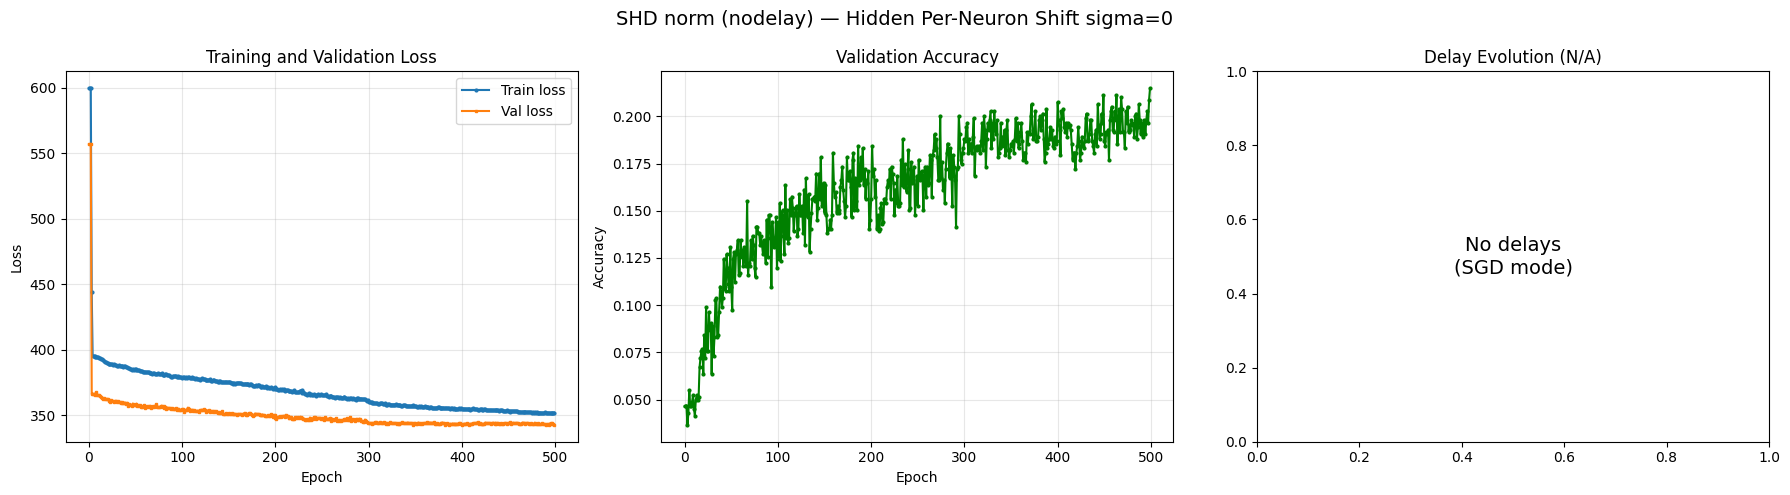


--- Training curves for sigma=1 ---


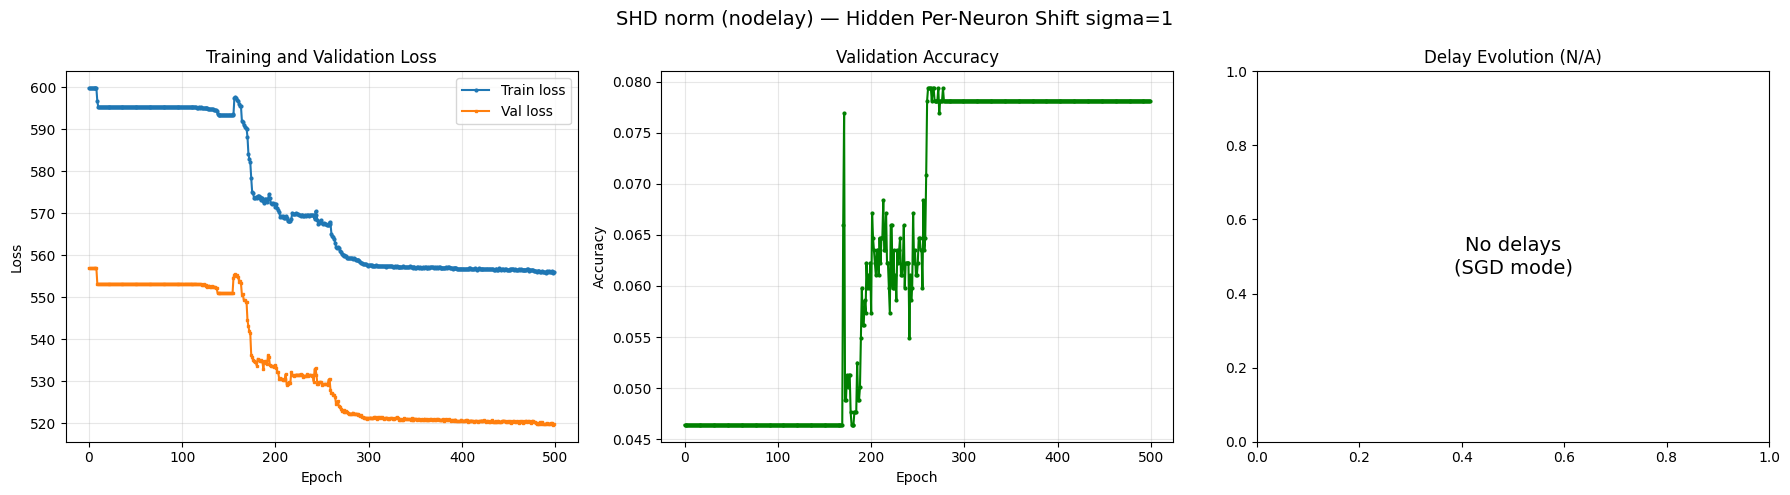


--- Training curves for sigma=3 ---


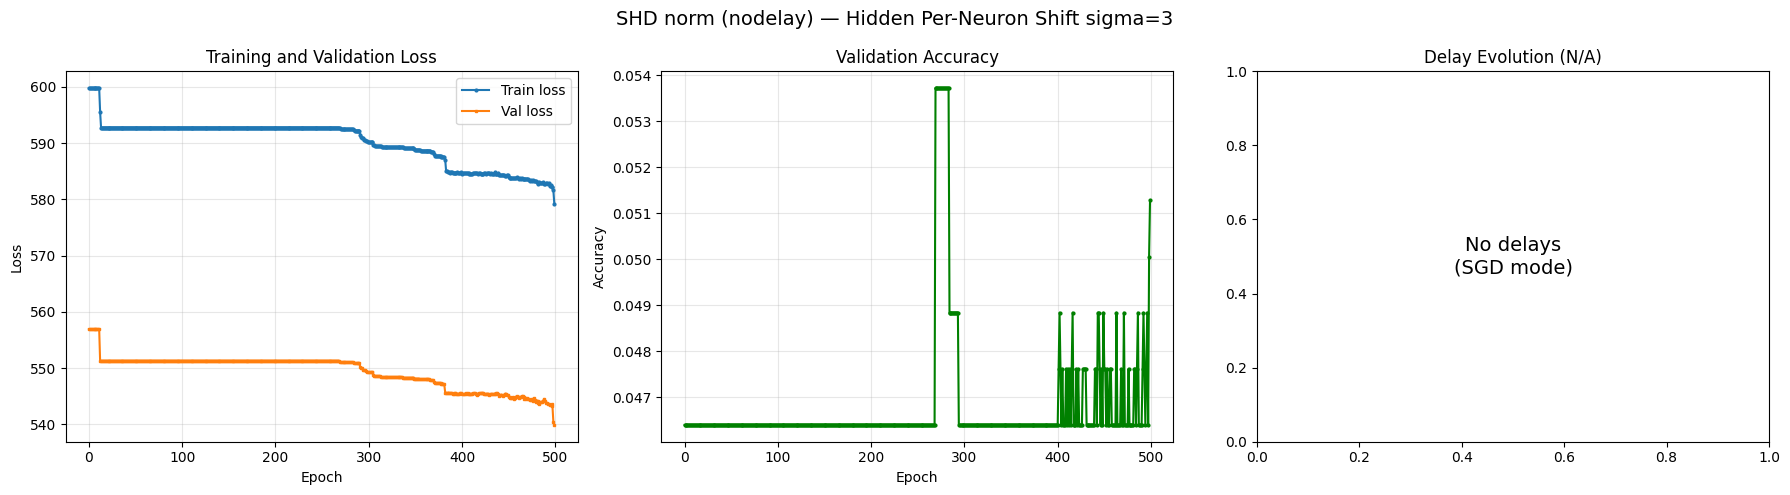


--- Training curves for sigma=5 ---


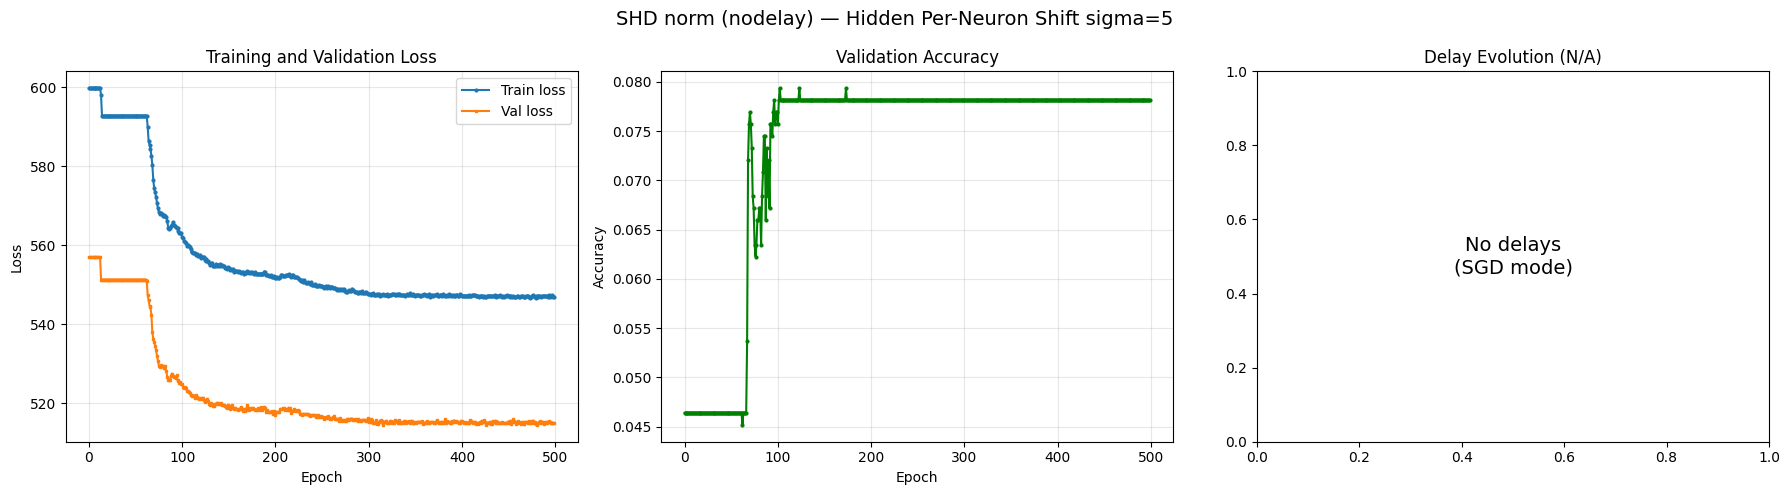


--- Training curves for sigma=10 ---


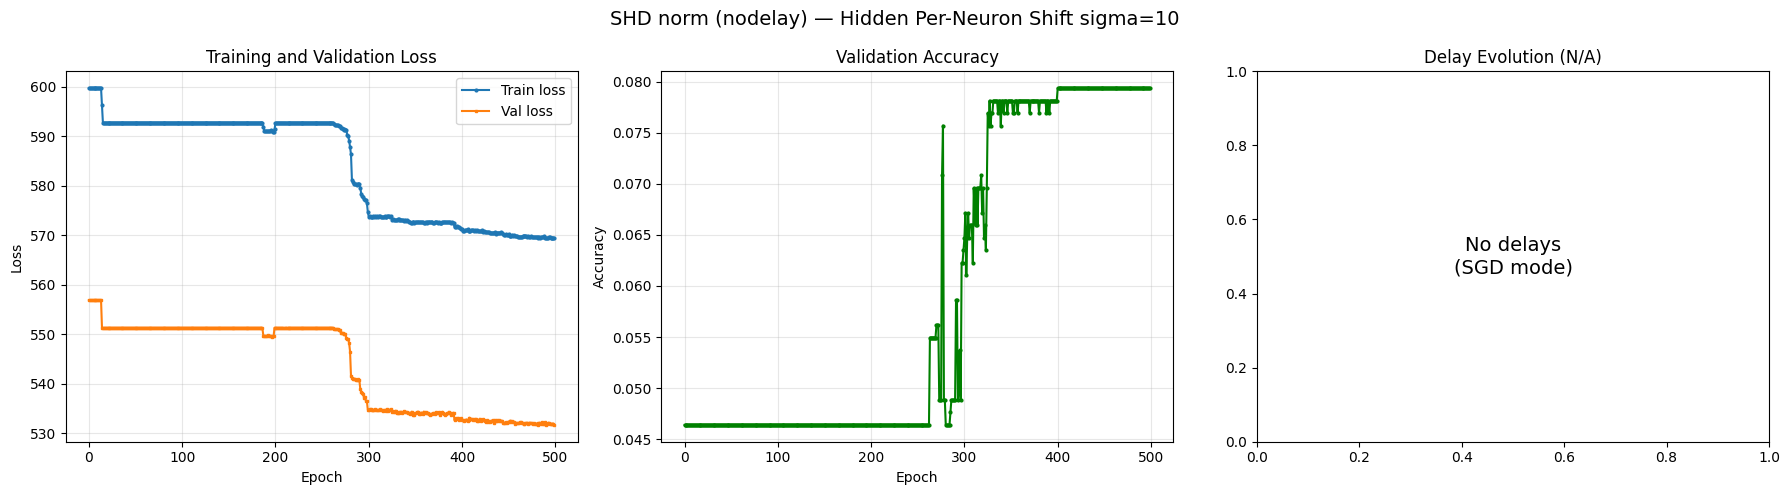


--- Training curves for sigma=17 ---


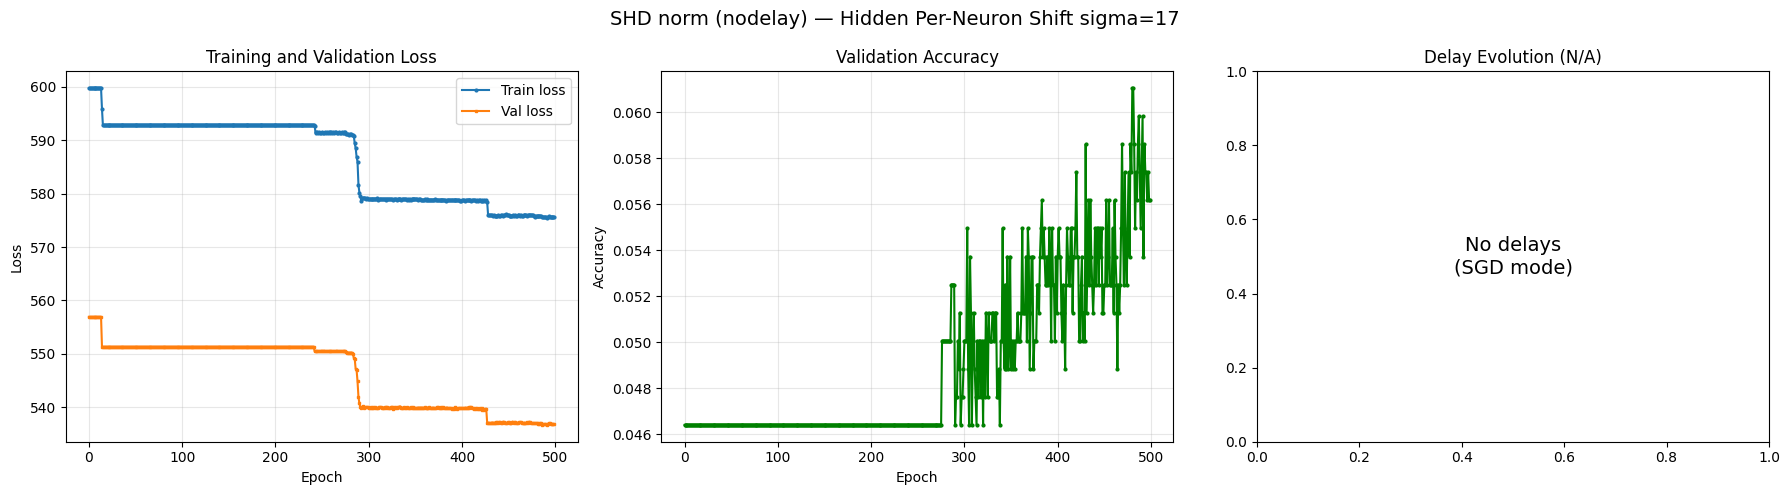


--- Training curves for sigma=25 ---


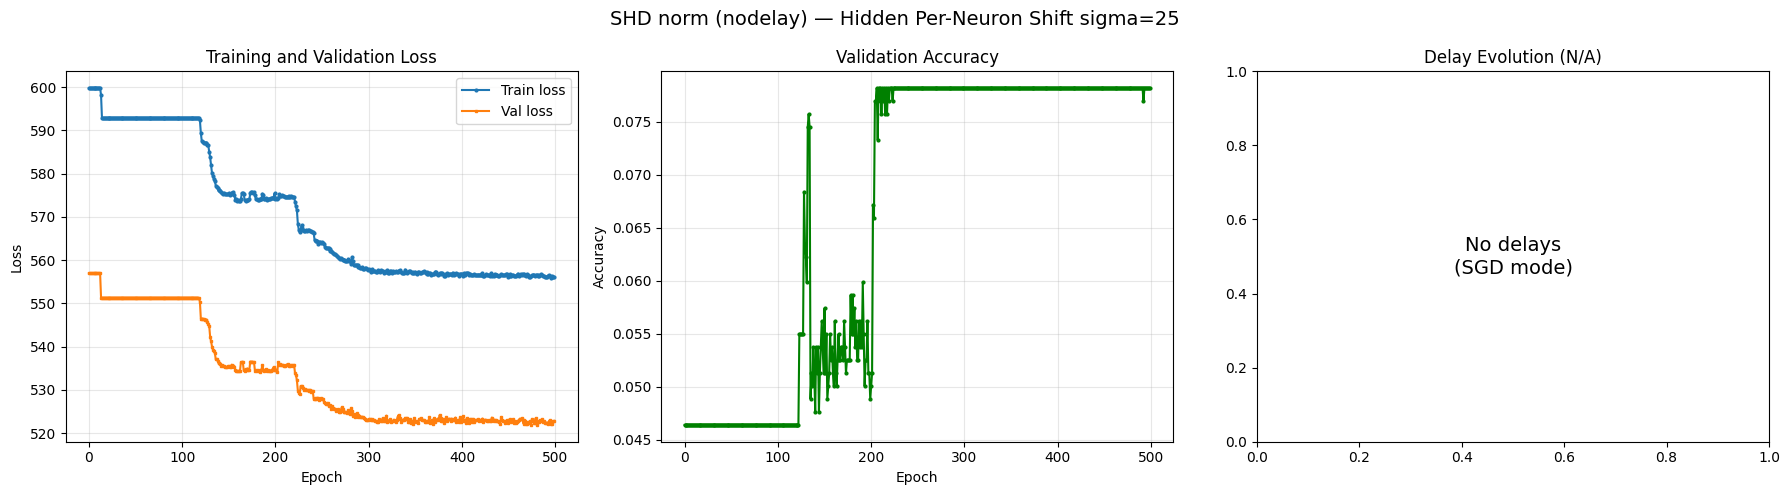

In [11]:
for sigma in SIGMA_VALUES:
    print(f"\n--- Training curves for sigma={sigma} ---")
    plot_training_curves(all_training_logs[sigma], sigma=sigma)

## 12. Plot Shift Sweep Results

The main result: test accuracy vs. hidden-layer per-neuron shift sigma across
all trained models.


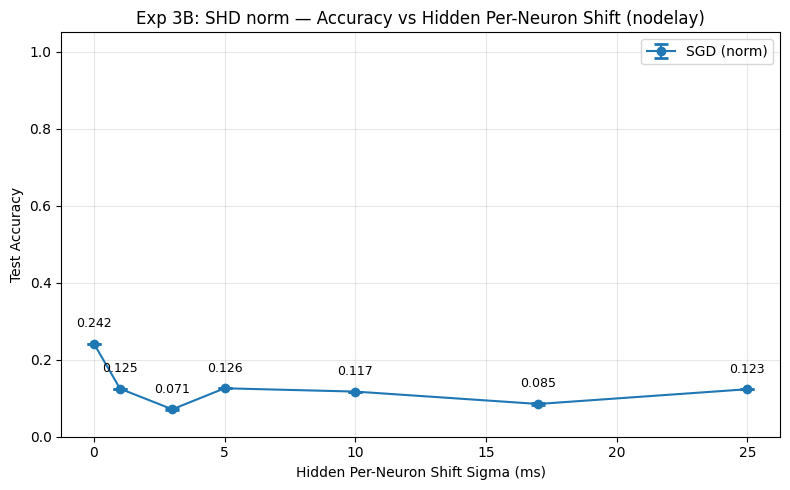

Figure saved to log/shift_norm_nodelay_shift_sweep.png


In [12]:
plot_shift_sweep_curve(all_test_results)

## 13. Save Results

Save the sweep results and all training logs to JSON for later comparison
across dataset variants and delay/no-delay modes.

In [13]:
# Save sweep results
sweep_serialisable = {
    str(sigma): {
        "mean": data["mean"],
        "std": data["std"],
        "values": [float(v) for v in data["values"]],
    }
    for sigma, data in all_test_results.items()
}

results_path = f"log/{MODEL_PREFIX}_shift_sweep_results.json"
with open(results_path, "w") as fp:
    json.dump(sweep_serialisable, fp, indent=2)
print(f"Sweep results saved to {results_path}")

# Save training logs for each sigma
for sigma, log in all_training_logs.items():
    log_path = f"log/{MODEL_PREFIX}_sigma{sigma}_training_log.json"
    log_serialisable = {
        k: [float(v) for v in vals] if isinstance(vals, list) else vals
        for k, vals in log.items()
    }
    with open(log_path, "w") as fp:
        json.dump(log_serialisable, fp, indent=2)
    print(f"Training log saved to {log_path}")

Sweep results saved to log/shift_norm_nodelay_shift_sweep_results.json
Training log saved to log/shift_norm_nodelay_sigma0_training_log.json
Training log saved to log/shift_norm_nodelay_sigma1_training_log.json
Training log saved to log/shift_norm_nodelay_sigma3_training_log.json
Training log saved to log/shift_norm_nodelay_sigma5_training_log.json
Training log saved to log/shift_norm_nodelay_sigma10_training_log.json
Training log saved to log/shift_norm_nodelay_sigma17_training_log.json
Training log saved to log/shift_norm_nodelay_sigma25_training_log.json


## 14. Model Analysis

Print delay statistics and weight statistics for each trained model.

In [14]:
for sigma in SIGMA_VALUES:
    net = all_trained_models[sigma]
    print(f"\n{'='*60}")
    print(f"  Model Analysis \u2014 sigma={sigma} ({DELAY_TAG})")
    print(f"{'='*60}")

    # Delay statistics
    delays = net.get_delays()
    if delays:
        for delay_name, delay_values in delays.items():
            if len(delay_values) > 0:
                print(
                    f"  {delay_name}: "
                    f"mean={np.mean(delay_values):.2f}, "
                    f"std={np.std(delay_values):.2f}, "
                    f"min={np.min(delay_values):.2f}, "
                    f"max={np.max(delay_values):.2f}"
                )
    else:
        print("  No delays (SGD mode)")

    # Weight statistics
    for name, param in net.named_parameters():
        if "weight" in name:
            w = param.data
            print(
                f"  {name}: mean={w.mean().item():.4f}, "
                f"std={w.std().item():.4f}, "
                f"shape={list(w.shape)}"
            )


  Model Analysis — sigma=0 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: mean=26.4270, std=19.2288, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=1.9006, std=8.1527, shape=[128, 224, 1, 1, 1]
  fc2.weight_g: mean=14.6963, std=22.4663, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.3523, std=4.3415, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=55.8258, std=29.5512, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=-0.0259, std=4.0466, shape=[20, 128, 1, 1, 1]

  Model Analysis — sigma=1 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: mean=5.7758, std=0.1568, shape=[128, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.0000, std=0.3861, shape=[128, 224, 1, 1, 1]
  fc2.weight_g: mean=13.1969, std=19.2484, shape=[128, 1, 1, 1, 1]
  fc2.weight_v: mean=0.1757, std=2.1379, shape=[128, 128, 1, 1, 1]
  fc3.weight_g: mean=73.3880, std=36.6615, shape=[20, 1, 1, 1, 1]
  fc3.weight_v: mean=0.1623, std=4.0731, shape=[20, 128, 1, 1, 1]

  Model Analysis — sigma=3 (nodelay)
  No delays (SGD mode)
  fc1.weight_g: 